# Análisis Exploratorio de Datos - E-commerce - InsightLab

Este notebook desarrolla el análisis exploratorio del dataset **Indian E-Commerce Customer Behavior & Purchase**.  
El objetivo del EDA es comprender el comportamiento de los usuarios dentro de la plataforma, identificar patrones asociados a la compra y detectar variables útiles para un modelo de predicción de intención de compra y promociones personalizadas.

## Objetivo del análisis

El análisis busca responder preguntas relacionadas con el problema de negocio:

- ¿Qué proporción de sesiones termina en compra?
- ¿Qué proporción de usuarios abandona el carrito?
- ¿Qué variables de navegación, descuento, producto o sesión se relacionan con la conversión?
- ¿Qué segmentos de comportamiento podrían recibir promociones o experiencias personalizadas?

## Importación de librerías

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cargar_datos import cargar_datos

## Carga de datos

La carga del dataset se realiza desde el archivo `cargar_datos.py`.  
Se mantiene la lógica de carga separada del análisis para que este notebook se concentre en el EDA.

In [64]:
data = cargar_datos()

Archivo cargado: Ecommerce.csv
Cantidad de filas: 25000
Cantidad de columnas: 29


In [65]:
data.head(15)

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118
5,8726,5,29-03-2024,1,0,4,481,3,458.42,2,...,1,0,1,29,3,4,1,Long,0.000000,207
6,1773,6,28-05-2024,0,1,1,634,0,623.83,4,...,3,0,5,28,5,1,1,Very Long,0.316289,175
7,7275,7,19-11-2024,1,0,4,225,6,1491.56,3,...,1,0,4,19,11,1,0,Long,0.000000,150
8,2813,8,13-02-2024,1,1,3,628,2,791.88,2,...,1,0,2,13,2,1,3,Very Short,0.000000,141
9,1847,9,29-07-2024,1,0,4,664,7,164.42,4,...,1,0,1,29,7,0,2,Short,0.000000,103


## Exploración inicial

En esta etapa se revisa la estructura general del dataset: cantidad de filas, columnas, tipos de datos y primeras observaciones.

In [66]:
print(f"Cantidad de filas: {data.shape[0]}")
print(f"Cantidad de columnas: {data.shape[1]}")

Cantidad de filas: 25000
Cantidad de columnas: 29


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [68]:
data.columns.tolist()

['customer_id',
 'session_id',
 'visit_date',
 'device_type',
 'user_type',
 'marketing_channel',
 'product_id',
 'product_category',
 'unit_price',
 'quantity',
 'discount_percent',
 'discount_amount',
 'revenue',
 'pages_viewed',
 'time_on_site_sec',
 'added_to_cart',
 'purchased',
 'cart_abandoned',
 'rating',
 'review_text',
 'review_helpful_votes',
 'payment_method',
 'visit_day',
 'visit_month',
 'visit_weekday',
 'visit_season',
 'session_duration_bucket',
 'revenue_normalized',
 'location']

## Observaciones adicionales sobre la estructura del dataset

Antes de avanzar con el análisis detallado, se registran algunas observaciones sobre la codificación y calidad de ciertas columnas, detectadas en una revisión visual inicial:

- **Variables categóricas codificadas numéricamente**: columnas como `device_type`, `marketing_channel`, `product_category` y `payment_method` están representadas como números, pero corresponden a categorías, no a magnitudes. El dataset no provee un diccionario que indique a qué categoría real corresponde cada número (por ejemplo, qué representa `product_category = 3`).


- **`location`**: contiene 225 valores únicos codificados numéricamente (0 a 224), probablemente representando ciudades o regiones de India (coherente con el origen del dataset). Al igual que las variables anteriores, no hay diccionario provisto por la fuente que permita decodificar el significado de cada valor.

- **`visit_season`**: agrupa el año en 4 bloques de 3 meses (trimestres calendario), no representa temporadas comerciales o climáticas específicas:
  - `0` → Septiembre, Octubre, Noviembre
  - `1` → Marzo, Abril, Mayo
  - `2` → Junio, Julio, Agosto
  - `3` → Diciembre, Enero, Febrero

- **`visit_date`**: el componente de hora, minuto y segundo es `00:00:00` en el 100% de los registros — el dataset solo registra el día de la visita, no un timestamp exacto.

- **Redundancia en variables temporales**: `visit_day`, `visit_month`, `visit_weekday` y `visit_season` ya vienen desagregados como columnas propias en el dataset original. La conversión de `visit_date` a formato fecha no aporta información nueva respecto a estas columnas, solo consolida el dato en un único campo de tipo fecha (útil para ordenar cronológicamente o graficar series de tiempo).

### Diccionario de categorías (según fuente original en Kaggle)

El dataset no incluye un diccionario de datos dentro del archivo CSV, pero la página de Kaggle donde se publicó el dataset aclara el significado de algunas columnas categóricas codificadas:

- **`device_type`**: `0` = Ordenador de escritorio (PC), `1` = Móvil, `2` = Tablet.
- **`user_type`**: `0` = Usuario nuevo, `1` = Usuario recurrente.

Para el resto de las variables categóricas codificadas numéricamente (`marketing_channel`, `product_category`, `payment_method`, `location`), la fuente no provee un diccionario. 
Se tratan como categorías nominales sin interpretar el significado específico de cada valor ya que no es posible confirmarlo y no resulta necesario para el modelado (los algoritmos de clasificación no requieren conocer el significado semántico de cada categoría para aprender patrones asociados a ellas).

## Selección final de variables para el modelado

A partir del análisis exploratorio y la revisión de posibles fugas de información (data leakage), se define el siguiente criterio de selección de variables:

### Variable objetivo (target)
- `purchased`: indica si la sesión terminó en compra (0 = No, 1 = Sí).

### Variables excluidas por fuga de información (leakage)
Estas variables solo existen o toman valores reales *después* de conocer el resultado de la compra, por lo que no estarían disponibles en el momento de predecir:

- `revenue`: ingreso generado por la sesión, es 0 si no hubo compra.
- `revenue_normalized`: versión normalizada de `revenue`, mismo problema.
- `cart_abandoned`: se verificó que es matemáticamente equivalente a "agregó al carrito y no compró" (`cart_abandoned = 1` si y solo si `added_to_cart = 1` y `purchased = 0`, sin excepciones en las 25.000 filas). Al incluirla como feature en una prueba de control, un modelo simple alcanzó 100% de precisión, confirmando que se trata de fuga directa de información.
- `rating`, `review_text`, `review_helpful_votes`: solo tienen valores reales si hubo compra; en caso contrario, `review_text` y `review_helpful_votes` valen 0 y `rating` queda con un valor de relleno.

### Variables excluidas por ser identificadores
No aportan patrones generalizables, son etiquetas únicas por registro:

- `customer_id`, `session_id`, `product_id`

### Variables redundantes (se elige una sola versión)
- Se mantiene `visit_date` (simplificada a solo año-mes-día, sin componente de hora) junto con `visit_season` como variables temporales. Se descartan `visit_day`, `visit_month` y `visit_weekday` por ser redundantes, ya que esa información queda contenida en `visit_date`.
- `session_duration_bucket` se descarta como feature de modelado en favor de `time_on_site_sec` (valor numérico exacto), ya que los algoritmos de clasificación pueden encontrar sus propios puntos de corte óptimos en lugar de usar una categorización predefinida. `session_duration_bucket` puede ser útil más adelante para reportes o visualizaciones orientadas a negocio, por su mayor legibilidad.


## Variables finales seleccionadas para el modelo

- `device_type`
- `user_type`
- `marketing_channel`
- `product_category`
- `unit_price`
- `quantity`
- `discount_percent`
- `discount_amount`
- `pages_viewed`
- `time_on_site_sec`
- `added_to_cart`
- `payment_method`
- `visit_date`
- `visit_season`
- `location`


### Conversión de fecha

La columna `visit_date` viene como texto. Se convierte a formato fecha para poder analizar comportamiento temporal.


In [69]:
data["visit_date"] = pd.to_datetime(
    data["visit_date"],
    format="%d-%m-%Y",
    errors="coerce"
).dt.date

data[["visit_date", "visit_season"]].head(20)

,visit_date,visit_season
0,2024-11-28,0
1,2024-09-25,0
2,2024-05-31,1
3,2024-01-30,3
4,2024-02-25,3
5,2024-03-29,1
6,2024-05-28,1
7,2024-11-19,0
8,2024-02-13,3
9,2024-07-29,2


## Revisión de valores nulos

In [70]:
print(f"\nValores nulos por columna:\n")
resumen_nulos = pd.DataFrame({
    "nulos": data.isnull().sum(),
    "porcentaje": data.isnull().mean() * 100
}).sort_values(by="porcentaje", ascending=False)

resumen_nulos


Valores nulos por columna:



,nulos,porcentaje
customer_id,0,0.0
session_id,0,0.0
visit_date,0,0.0
device_type,0,0.0
user_type,0,0.0
marketing_channel,0,0.0
product_id,0,0.0
product_category,0,0.0
unit_price,0,0.0
quantity,0,0.0


El análisis de nulos permite determinar si existen columnas incompletas que requieran tratamiento antes del modelado.

## Revisión de duplicados

In [71]:
duplicados = data.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


## Clasificación de variables

Aunque muchas columnas están codificadas como números, no todas deben interpretarse como variables numéricas continuas.  
Por ejemplo, `device_type`, `marketing_channel`, `product_category` o `payment_method` representan categorías codificadas.

In [72]:
TARGET = "purchased"

columnas_id = [
    "customer_id",
    "session_id",
    "product_id"
]

columnas_categoricas = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "purchased",
    "cart_abandoned",
    "rating",
    "review_text",
    "payment_method",
    "visit_day",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

columnas_numericas = [
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "revenue",
    "pages_viewed",
    "time_on_site_sec",
    "review_helpful_votes",
    "revenue_normalized"
]

print("Columnas identificadoras:")
print(columnas_id)

print("\nColumnas categóricas/codificadas:")
print(columnas_categoricas)

print("\nColumnas numéricas:")
print(columnas_numericas)

Columnas identificadoras:
['customer_id', 'session_id', 'product_id']

Columnas categóricas/codificadas:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']

Columnas numéricas:
['unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'review_helpful_votes', 'revenue_normalized']


In [73]:
for columna in columnas_categoricas:
    data[columna] = data[columna].astype("category")

data.dtypes

customer_id                   int64
session_id                    int64
visit_date                   object
device_type                category
user_type                  category
marketing_channel          category
product_id                    int64
product_category           category
unit_price                  float64
quantity                      int64
discount_percent              int64
discount_amount             float64
revenue                     float64
pages_viewed                  int64
time_on_site_sec              int64
added_to_cart              category
purchased                  category
cart_abandoned             category
rating                     category
review_text                category
review_helpful_votes          int64
payment_method             category
visit_day                  category
visit_month                category
visit_weekday              category
visit_season               category
session_duration_bucket    category
revenue_normalized          

### Conversión de tipos de datos

Las columnas identificadas como categóricas están codificadas numéricamente, pero no representan cantidades. Se convierten explícitamente al tipo `category` de pandas para evitar que se traten como variables numéricas continuas en análisis posteriores (por ejemplo, al calcular promedios o incluirlas sin querer en un `describe()` de variables numéricas).

## Estadísticas descriptivas

Primero se revisan las variables numéricas para entender escalas, dispersión, mínimos, máximos y posibles valores atípicos.

In [74]:
data[columnas_numericas].describe()

,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,review_helpful_votes,revenue_normalized
count,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000
mean,782.319010,2.489040,8.99880,174.997669,404.646762,12.535840,903.262920,5.52080,0.051290
std,476.612168,1.114563,9.26364,269.005411,1022.391774,6.929762,518.676202,12.33629,0.129591
min,50.050000,1.000000,0.00000,0.000000,0.000000,1.000000,10.000000,0.00000,0.000000
25%,395.222500,1.000000,0.00000,0.000000,0.000000,7.000000,453.000000,0.00000,0.000000
50%,691.725000,2.000000,10.00000,65.815000,0.000000,13.000000,903.000000,0.00000,0.000000
75%,1096.842500,3.000000,15.00000,240.355000,0.000000,19.000000,1355.000000,0.00000,0.000000
max,1999.830000,4.000000,30.00000,2388.260000,7889.360000,24.000000,1799.000000,49.00000,1.000000


**Interpretación de las estadísticas descriptivas:**

- `unit_price`: los precios van de $50 a casi $2000, con una media de $782. No se observan valores extremos o negativos que indiquen error de carga.
- `quantity`: la mayoría de las sesiones compran entre 1 y 3 unidades (75% de los casos), con un máximo de 4 unidades por sesión.
- `discount_percent`: el 50% de las sesiones no tiene descuento aplicado (mediana en 0%), y cuando lo hay, llega hasta el 30%.
- `discount_amount`: sigue el mismo patrón que el porcentaje — la mitad de las sesiones no tiene descuento, y el monto máximo ronda los $2388.

## Distribución de la variable objetivo

La variable `purchased` indica si una sesión terminó en compra.  
Esta distribución permite evaluar el balance del problema de clasificación.

In [75]:
distribucion_target = pd.DataFrame({
    "cantidad": data[TARGET].value_counts(),
    "porcentaje": data[TARGET].value_counts(normalize=True).multiply(100).round(2)
})

distribucion_target

,cantidad,porcentaje
purchased,,
0,19384,77.54
1,5616,22.46


**Interpretación:** el dataset está desbalanceado — el 77.54% de las sesiones no termina en compra mientras que solo el 22.46% sí compra. 
Este desbalance debe tenerse en cuenta al elegir las métricas de evaluación del modelo en la etapa de modelado (el accuracy por sí solo puede ser engañoso; conviene priorizar precision, recall o F1).

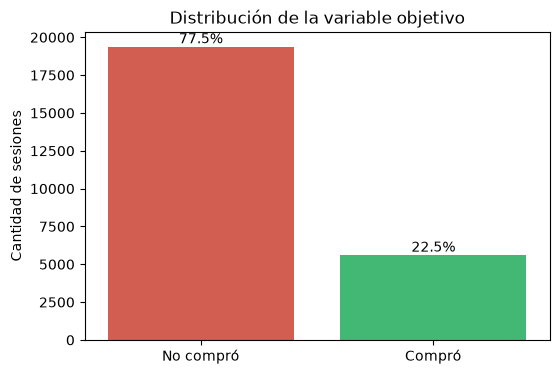

In [76]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=data,
    x=TARGET,
    hue=TARGET,
    palette=["#e74c3c", "#2ecc71"],
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No compró", "Compró"])

for p in ax.patches:
    pct = 100 * p.get_height() / len(data)
    ax.annotate(
        f'{pct:.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Distribución de la variable objetivo")
plt.xlabel("")
plt.ylabel("Cantidad de sesiones")
plt.show()

## Análisis univariado de variables numéricas

Se visualizan distribuciones y boxplots de las siguientes variables numéricas: `unit_price`, `quantity`, `discount_percent`, `discount_amount`, `pages_viewed` y `time_on_site_sec`. 

Este análisis permite detectar asimetrías, concentración de valores y posibles outliers en cada una.

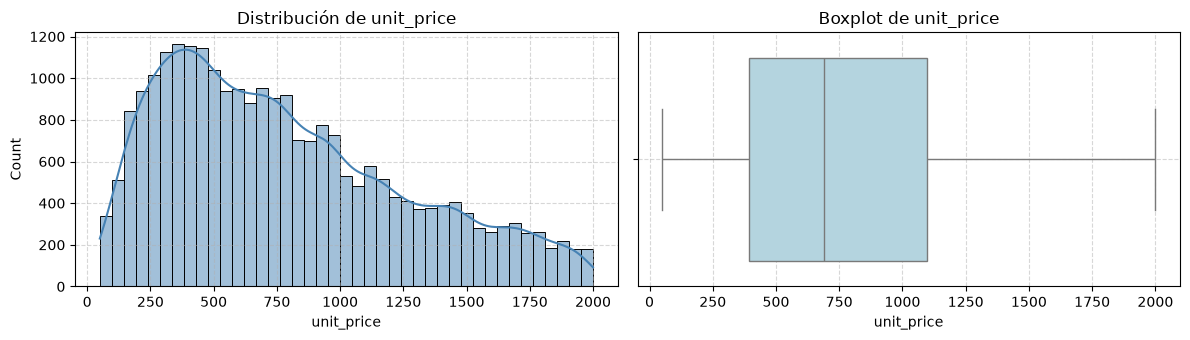

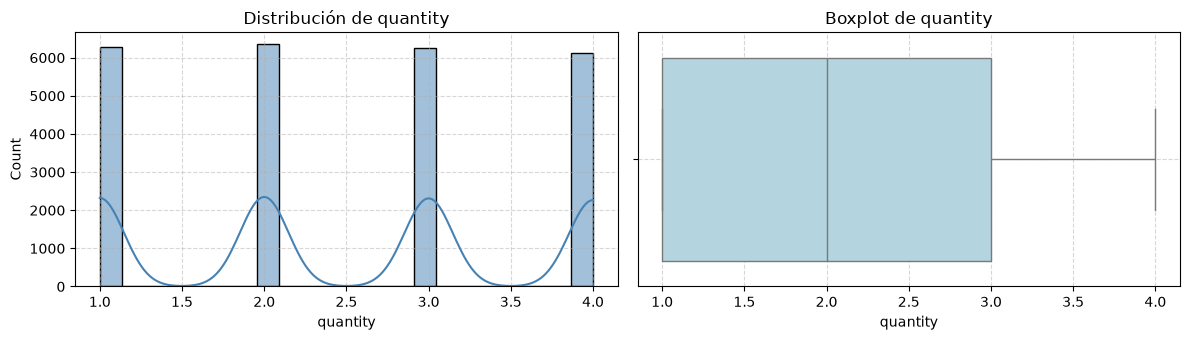

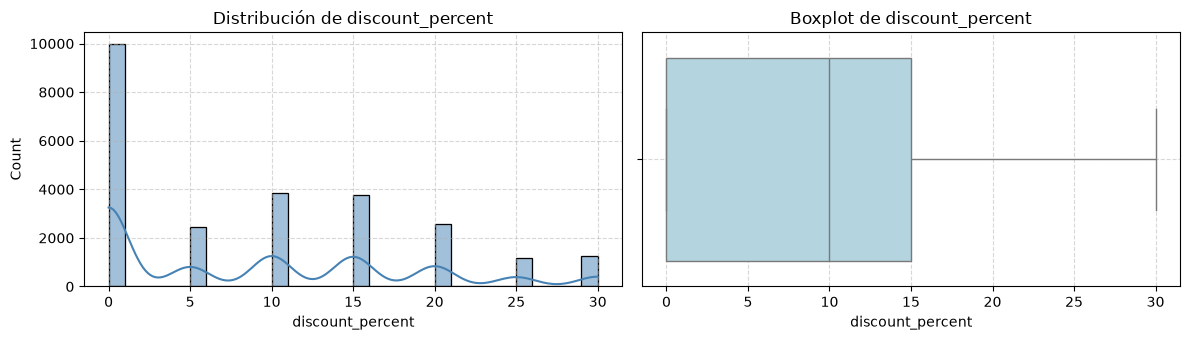

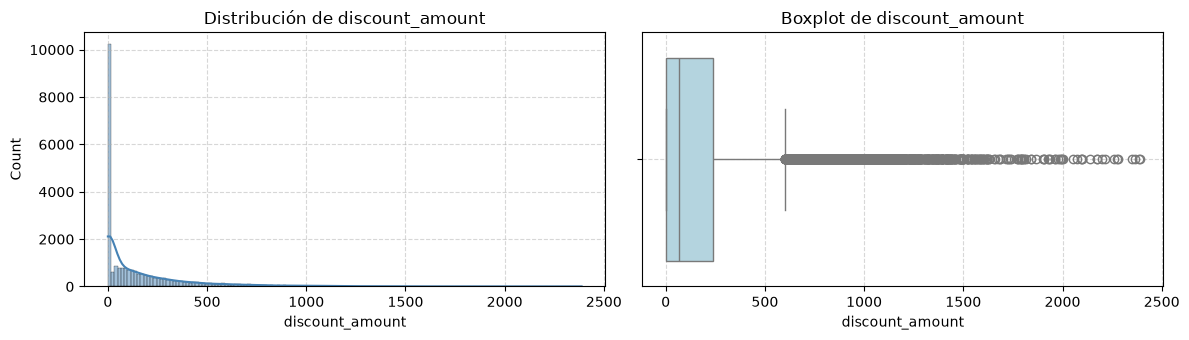

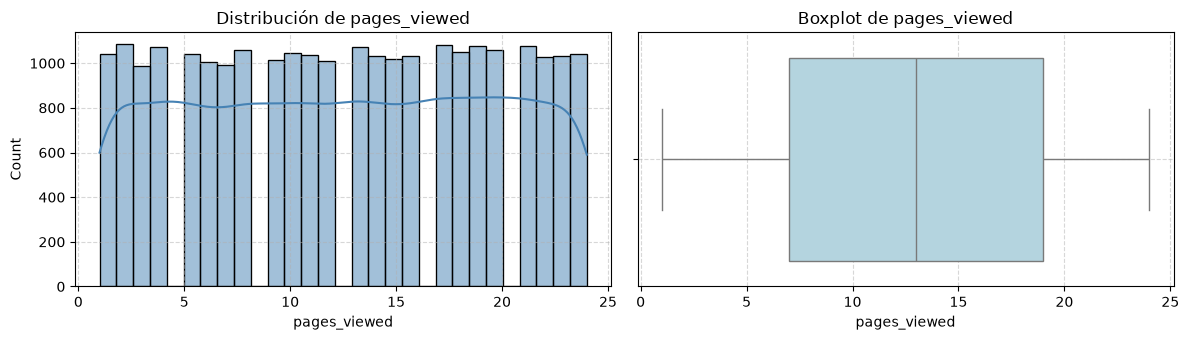

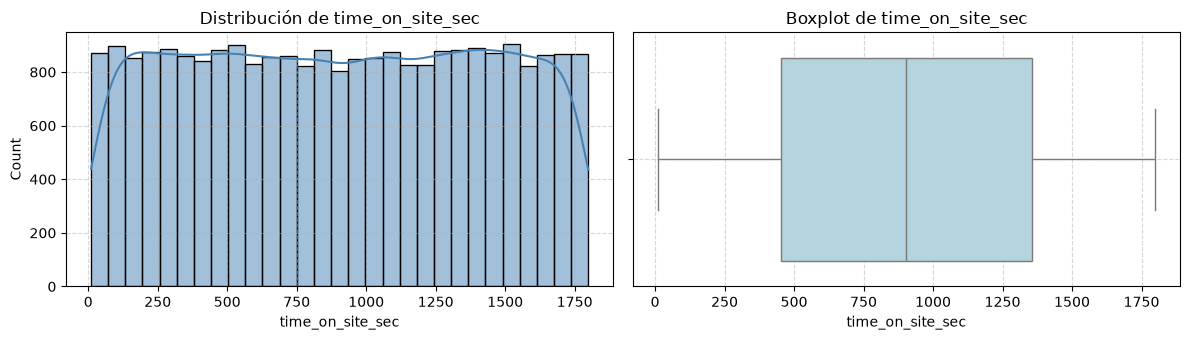

In [77]:
columnas_numericas_sanas = [c for c in columnas_numericas if c not in ["revenue", "revenue_normalized", "review_helpful_votes"]]

for columna in columnas_numericas_sanas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    sns.histplot(
        data=data,
        x=columna,
        kde=True,
        ax=axes[0],
        color="steelblue"
    )
    axes[0].set_title(f"Distribución de {columna}")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    sns.boxplot(
        data=data,
        x=columna,
        ax=axes[1],
        color="lightblue"
    )
    axes[1].set_title(f"Boxplot de {columna}")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

**Nota:** `revenue`, `revenue_normalized` y `review_helpful_votes` se excluyen del análisis univariado general porque toman valor 0 para las sesiones sin compra, generando boxplots poco informativos (concentración masiva en 0). Se analizan por separado a continuación, comparando únicamente entre sesiones con y sin compra.

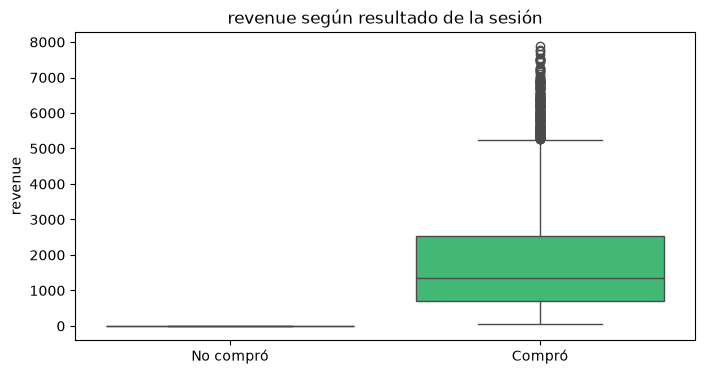

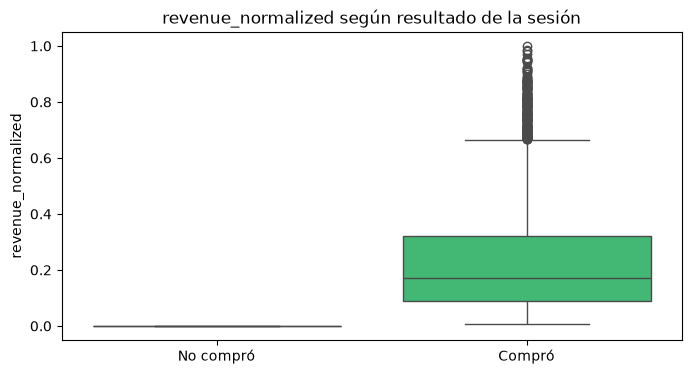

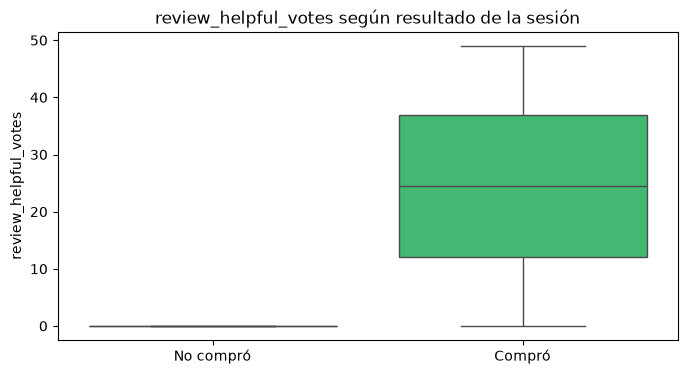

In [78]:
columnas_con_leakage = ["revenue", "revenue_normalized", "review_helpful_votes"]

for columna in columnas_con_leakage:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=data,
        x=TARGET,
        y=columna,
        hue=TARGET,
        palette=["#e74c3c", "#2ecc71"],
        legend=False
    )
    plt.xticks([0, 1], ["No compró", "Compró"])
    plt.title(f"{columna} según resultado de la sesión")
    plt.xlabel("")
    plt.show()

## Análisis formal de outliers (método IQR)

Los gráficos de la sección anterior permiten una primera aproximación visual a los valores atípicos, pero no cuantifican con precisión cuántos registros caen fuera del rango esperado. A continuación se aplica el método del **rango intercuartílico (IQR)** sobre las mismas seis variables numéricas revisadas en la sección anterior (`unit_price`, `quantity`, `discount_percent`, `discount_amount`, `pages_viewed`, `time_on_site_sec`), para determinar de forma objetiva qué proporción de cada columna corresponde a valores atípicos.

El método consiste en calcular:
- **Q1** (percentil 25) y **Q3** (percentil 75) de cada variable
- **IQR = Q3 - Q1**
- Límite inferior = Q1 - 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

Cualquier valor fuera de ese rango se considera un outlier según este criterio.

In [79]:
columnas_a_revisar = ["unit_price", "quantity", "discount_percent", "discount_amount", "pages_viewed", "time_on_site_sec"]

resumen_outliers = []

for columna in columnas_a_revisar:
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

    resumen_outliers.append({
        "columna": columna,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "cantidad_outliers": len(outliers),
        "porcentaje_outliers": round(100 * len(outliers) / len(data), 2)
    })

resumen_outliers_df = pd.DataFrame(resumen_outliers)
resumen_outliers_df

,columna,Q1,Q3,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,unit_price,395.22,1096.84,-657.21,2149.27,0,0.00
1,quantity,1.00,3.00,-2.00,6.00,0,0.00
2,discount_percent,0.00,15.00,-22.50,37.50,0,0.00
3,discount_amount,0.00,240.36,-360.53,600.89,1883,7.53
4,pages_viewed,7.00,19.00,-11.00,37.00,0,0.00
5,time_on_site_sec,453.00,1355.00,-900.00,2708.00,0,0.00


**Interpretación de las variables numéricas analizadas**

- ¿Por qué esta columna en particular y no otra tiene este comportamiento? 

Porque es la única variable numérica del grupo que combina dos cosas: un montón de sesiones en cero exacto **(sin descuento)** + una cola de valores que dependen del precio del producto (discount_amount = unit_price × discount_percent / 100) — entonces varía mucho según qué tan caro era el producto. 
Las otras columnas (unit_price, quantity, pages_viewed, time_on_site_sec) no tienen ese "montón en cero", por eso salen limpias con el método IQR.

In [80]:
data["discount_amount_log"] = np.log1p(data["discount_amount"])

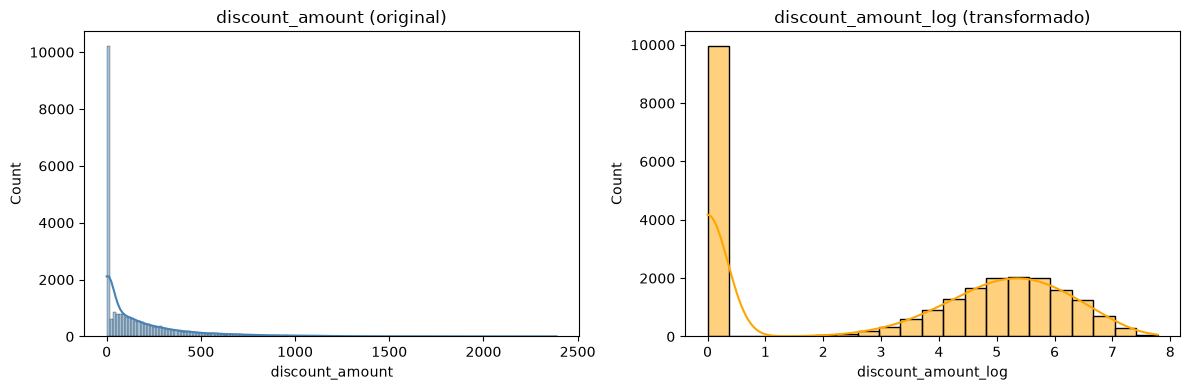

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data["discount_amount"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("discount_amount (original)")

sns.histplot(data["discount_amount_log"], kde=True, ax=axes[1], color="orange")
axes[1].set_title("discount_amount_log (transformado)")

plt.tight_layout()
plt.show()

**Decisión (actualizada):** se decide crear una columna adicional `discount_amount_log`, aplicando una transformación logarítmica (`log1p`) sobre `discount_amount`, en lugar de eliminar o modificar los valores atípicos. 

- Se mantiene también la columna original sin transformar, para uso en reportes de negocio donde la interpretabilidad en unidades monetarias es preferible. 
Como la transformación logarítmica es monótona, no afecta el desempeño de modelos basados en árboles (Decision Tree, XGBoost) y beneficia a modelos sensibles a la escala como la regresión logística — por lo tanto, se aplica de forma preventiva, sin costo para ninguna de las familias de modelos que se evaluarán en la etapa de modelado.

## Consolidación de variables numericas para el modelado

A modo de cierre del análisis exploratorio se define el conjunto final de columnas a utilizar en las siguientes etapas (preparación de datos, feature engineering y entrenamiento de modelos), en base a las decisiones documentadas a lo largo de este notebook.

In [82]:
target = "purchased"

features_finales = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "discount_amount_log",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart",
    "payment_method",
    "visit_date",
    "visit_season",
    "location"
]

data_final = data[features_finales + [target]].copy()
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   device_type          25000 non-null  category
 1   user_type            25000 non-null  category
 2   marketing_channel    25000 non-null  category
 3   product_category     25000 non-null  category
 4   unit_price           25000 non-null  float64 
 5   quantity             25000 non-null  int64   
 6   discount_percent     25000 non-null  int64   
 7   discount_amount      25000 non-null  float64 
 8   discount_amount_log  25000 non-null  float64 
 9   pages_viewed         25000 non-null  int64   
 10  time_on_site_sec     25000 non-null  int64   
 11  added_to_cart        25000 non-null  category
 12  payment_method       25000 non-null  category
 13  visit_date           25000 non-null  object  
 14  visit_season         25000 non-null  category
 15  location           

## Análisis de variables categóricas

Se revisa la distribución de las principales variables categóricas o codificadas.  
Al estar codificadas numéricamente, los valores representan clases y no magnitudes.

**Nota:** de esta lista, `cart_abandoned` y `rating` se excluyen del modelo por fuga de información (leakage), y `visit_month`, `visit_weekday` y `session_duration_bucket` se excluyen por ser redundantes con `visit_date`/`visit_season` y `time_on_site_sec` respectivamente (ver sección de "Selección final de variables"). Se incluyen igual en este análisis descriptivo para tener una visión completa del dataset.

In [83]:
categoricas_para_graficar = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "cart_abandoned",
    "rating",
    "payment_method",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket"
]

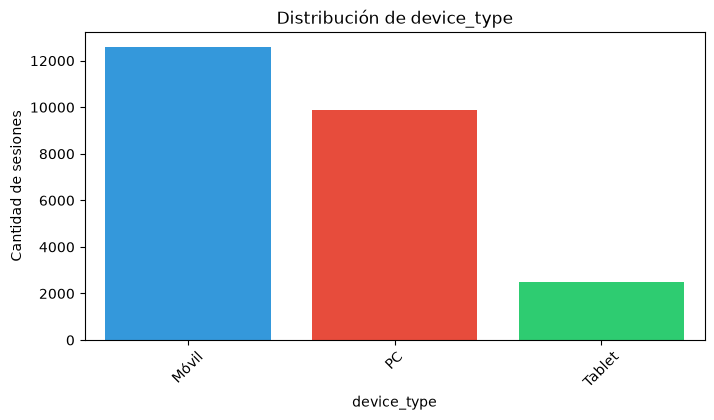

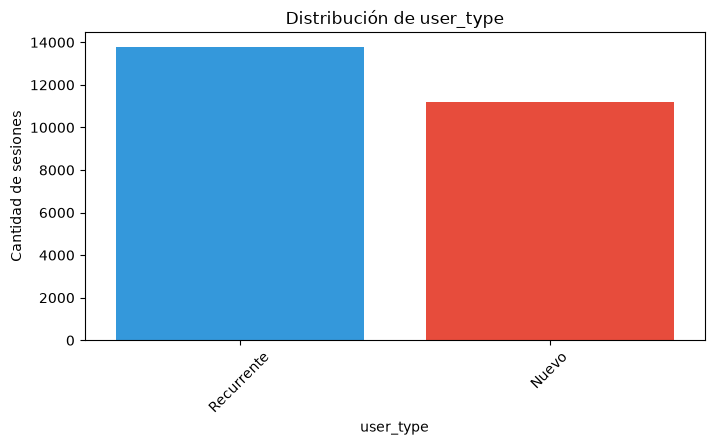

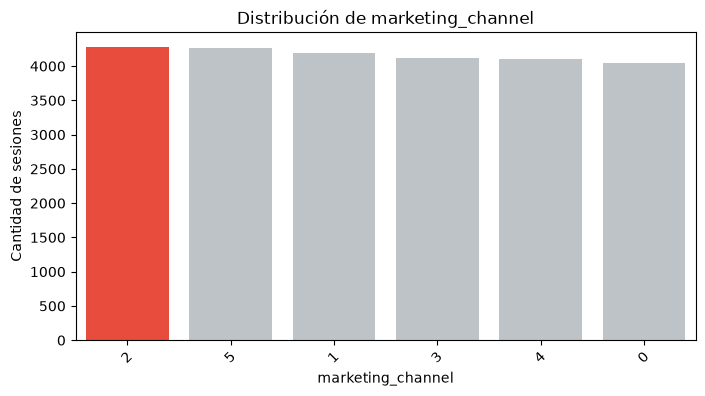

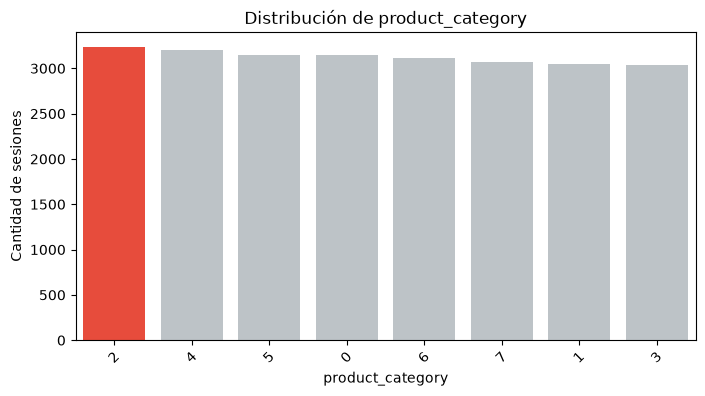

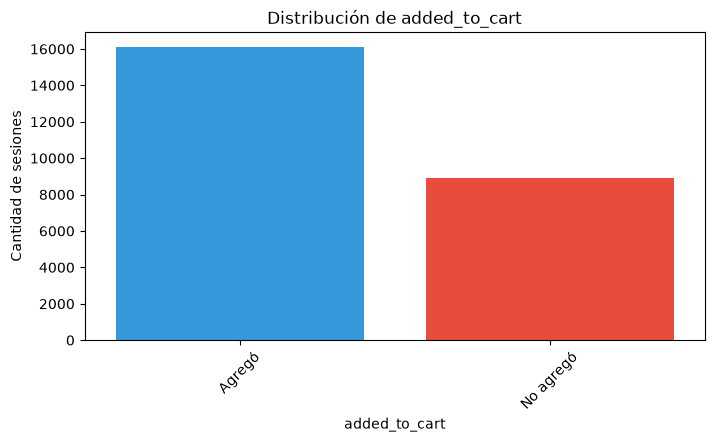

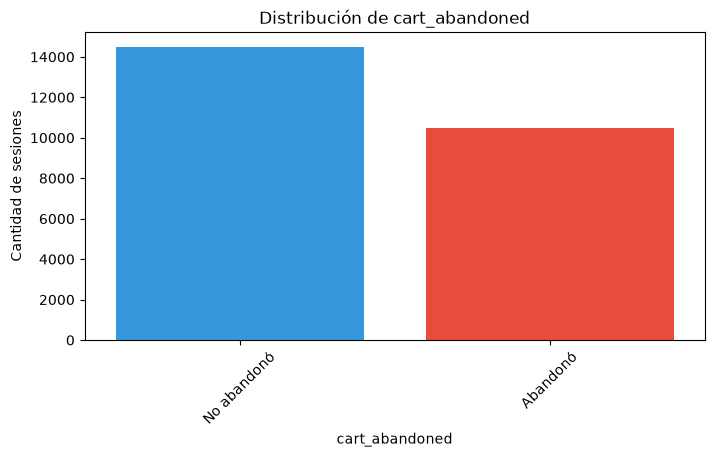

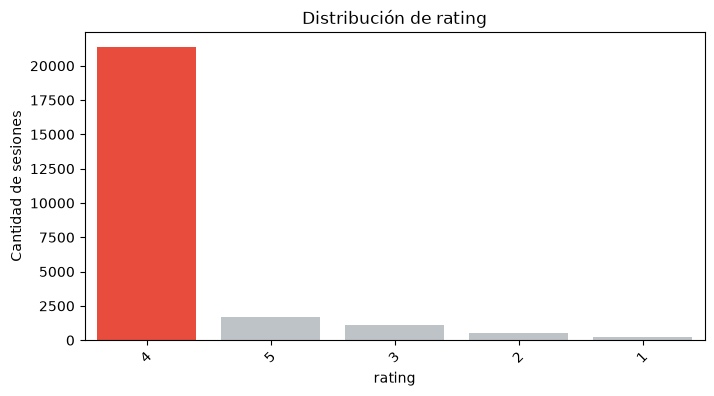

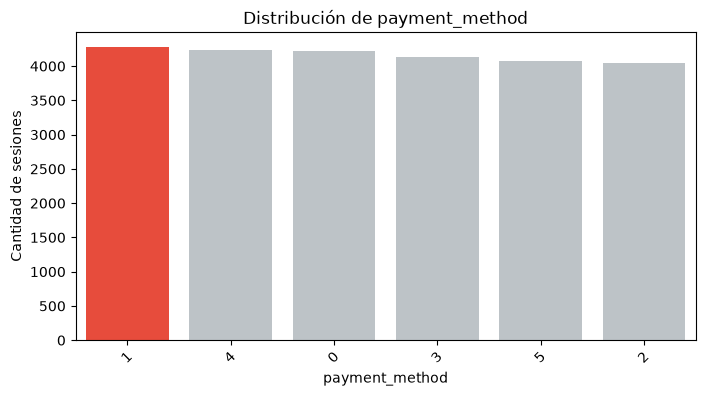

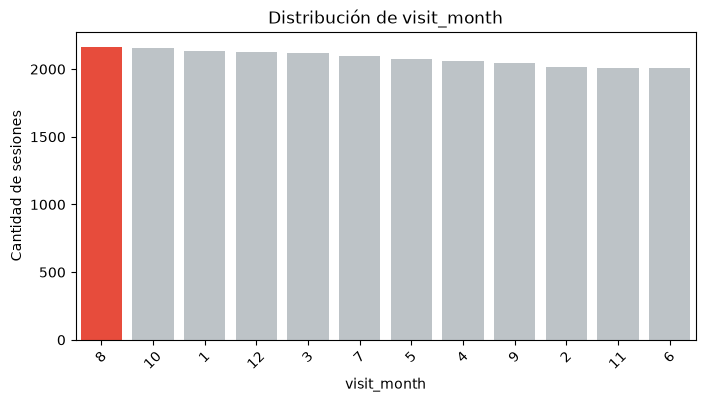

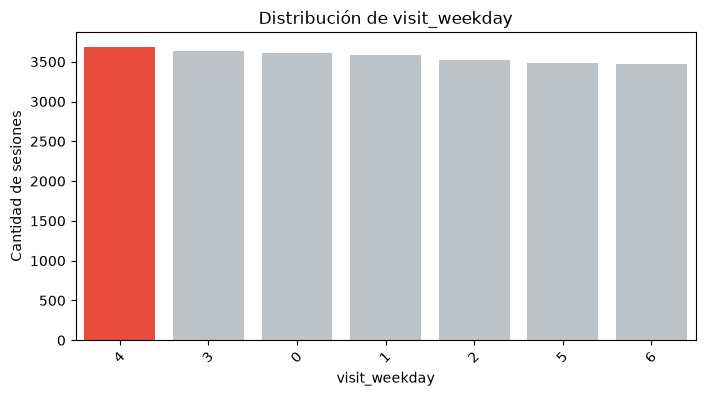

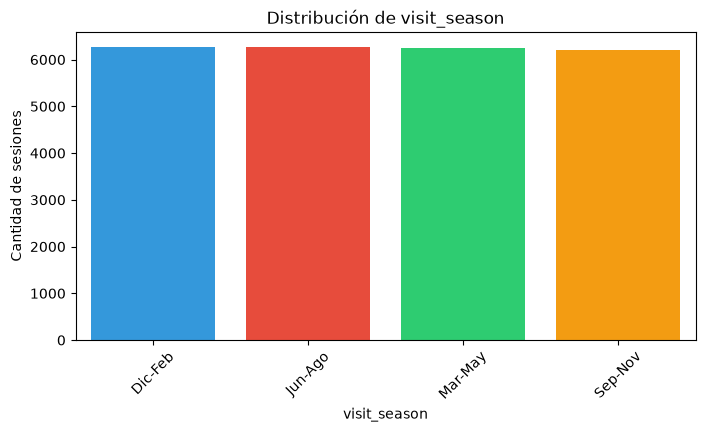

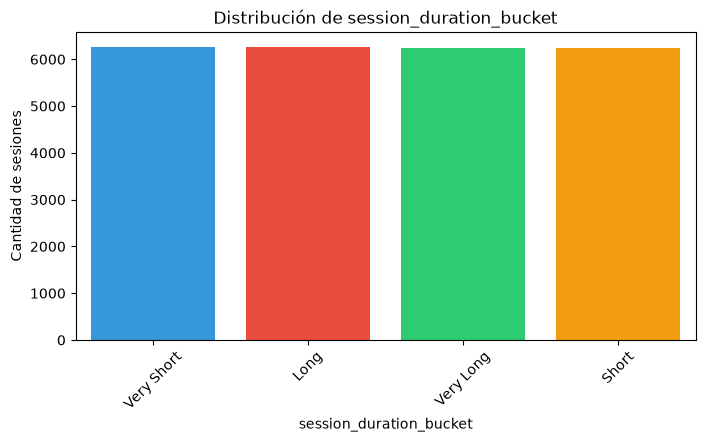

In [84]:
mapeo_etiquetas = {
    "device_type": {0: "PC", 1: "Móvil", 2: "Tablet"},
    "user_type": {0: "Nuevo", 1: "Recurrente"},
    "added_to_cart": {0: "No agregó", 1: "Agregó"},
    "cart_abandoned": {0: "No abandonó", 1: "Abandonó"},
    "visit_season": {0: "Sep-Nov", 1: "Mar-May", 2: "Jun-Ago", 3: "Dic-Feb"},
}

for columna in categoricas_para_graficar:
    plt.figure(figsize=(8, 4))

    orden = data[columna].value_counts().index
    cantidad_categorias = len(orden)

    if cantidad_categorias <= 4:
        colores = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"][:cantidad_categorias]
    else:
        colores = ["#bdc3c7"] * cantidad_categorias
        colores[0] = "#e74c3c"

    ax = sns.countplot(
        data=data,
        x=columna,
        order=orden,
        color="steelblue"
    )

    for patch, color in zip(ax.patches, colores):
        patch.set_facecolor(color)

    ax.set_xticks(range(cantidad_categorias))

    if columna in mapeo_etiquetas:
        etiquetas = [mapeo_etiquetas[columna].get(val, val) for val in orden]
        ax.set_xticklabels(etiquetas)
    else:
        ax.set_xticklabels(orden)

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad de sesiones")
    plt.xticks(rotation=45)
    plt.show()

## Tasa de conversión por variables categóricas

Se calcula la tasa de conversión promedio para distintas variables categóricas.  
Esto permite detectar categorías, canales, dispositivos o períodos con mejor desempeño comercial.

In [88]:
def graficar_conversion_por_categoria(df, columna, target=TARGET, top=None):
    
    conversion = (
    df.groupby(columna, observed=True)[target]
    .apply(lambda x: x.astype(int).mean())
    .sort_values(ascending=False)
)

    if top is not None:
        conversion = conversion.head(top)
    
    display(conversion.multiply(100).round(2).to_frame("tasa_conversion_%"))

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=conversion.index.astype(str),
        y=conversion.values * 100,
        color="steelblue"
    )

    plt.title(f"Tasa de conversión según {columna}")
    plt.xlabel(columna)
    plt.ylabel("Tasa de conversión (%)")
    plt.xticks(rotation=45)
    plt.show()

,tasa_conversion_%
device_type,
2,23.20
0,22.46
1,22.32


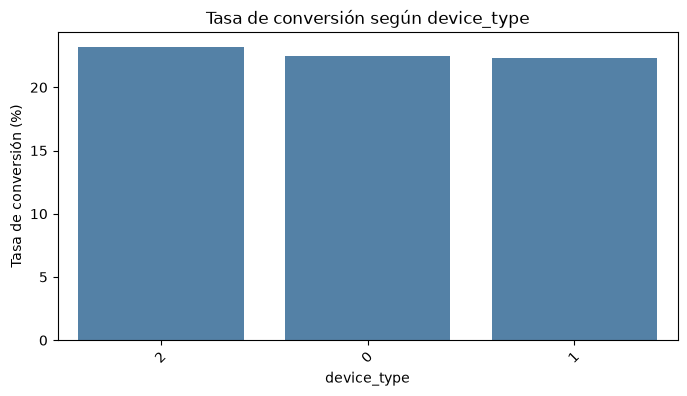

,tasa_conversion_%
user_type,
1,25.65
0,18.55


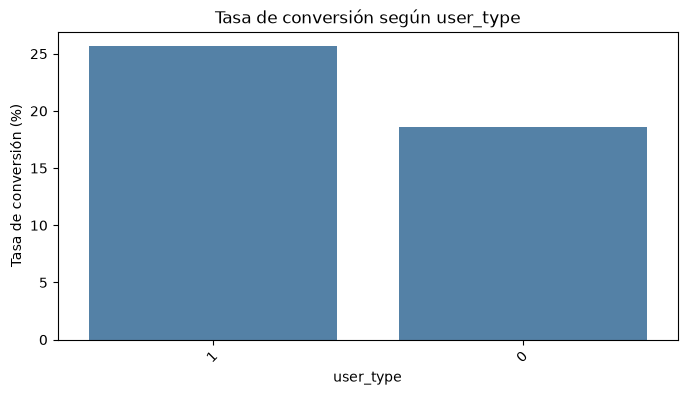

,tasa_conversion_%
marketing_channel,
5,23.60
0,22.72
3,22.64
1,22.12
2,22.03
4,21.66


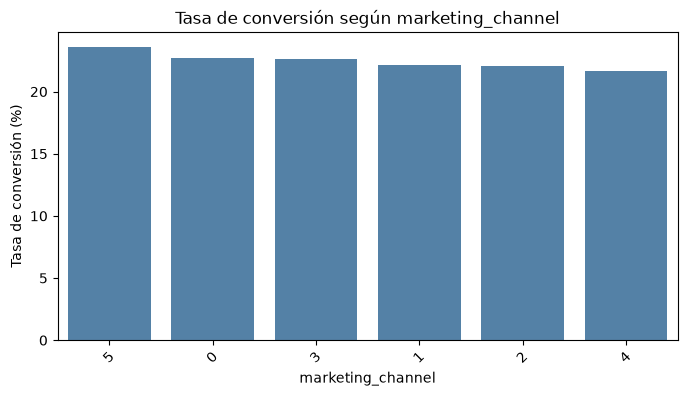

,tasa_conversion_%
product_category,
6,24.68
5,23.12
4,22.69
7,22.58
0,22.28
2,22.27
1,21.26
3,20.76


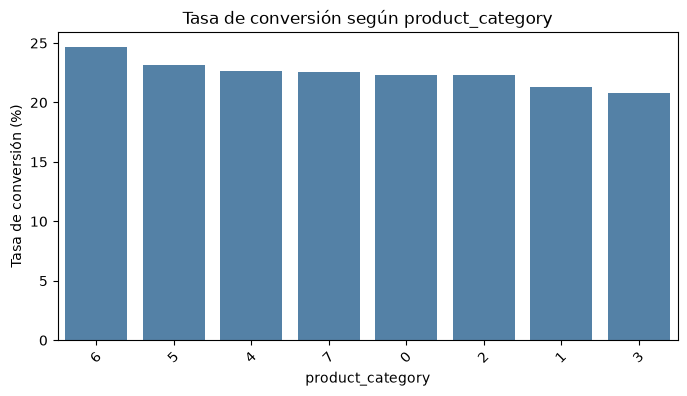

,tasa_conversion_%
payment_method,
2,23.20
3,22.92
1,22.89
5,22.42
4,22.20
0,21.17


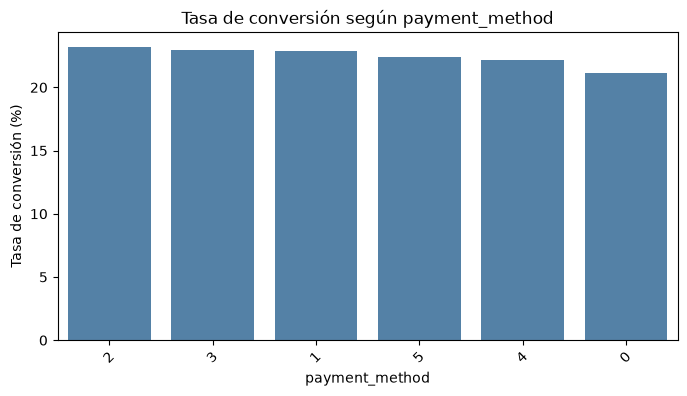

,tasa_conversion_%
session_duration_bucket,
Long,23.62
Very Long,23.22
Short,22.79
Very Short,20.24


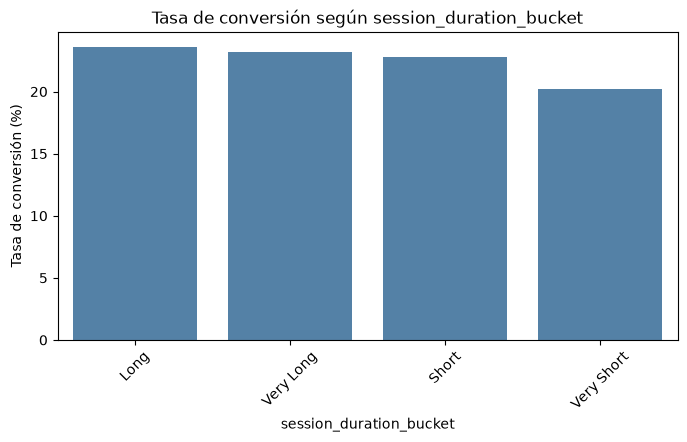

In [89]:
for columna in [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "session_duration_bucket"
]:
    graficar_conversion_por_categoria(data, columna)

,tasa_conversion_%
rating,
1,100.00
2,100.00
3,100.00
5,100.00
4,9.33


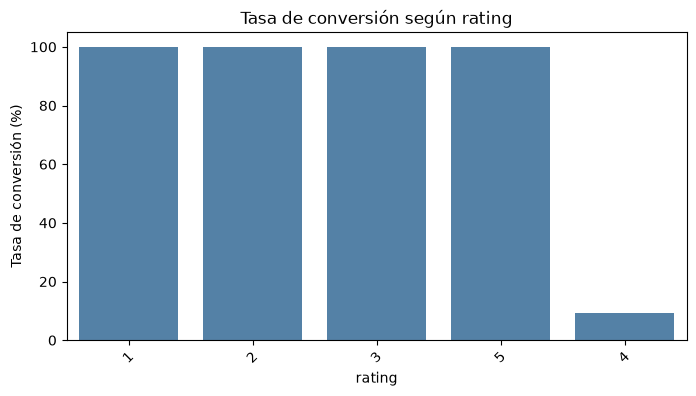

In [90]:
graficar_conversion_por_categoria(data, "rating")

**Evidencia del leakage en `rating`:**

Toda compra realizada tiene rating 1, 2, 3 o 5. Toda sesión sin compra tiene rating 4. Esto indica que el 4 no es una calificación real, sino un valor de relleno.

**Decisión:** se descarta `rating` como feature de análisis y modelado. No se elimina ningún registro del dataset.

## Análisis de descuentos

El descuento es central para el proyecto porque las promociones personalizadas serán una de las acciones comerciales propuestas.

- se crea la variable nueva `tuvo_descuento` (booleana: True/False), a partir de `discount_percent > 0`, para simplificar el análisis a nivel "hubo o no hubo descuento", sin importar el monto exacto.

In [94]:
data["tuvo_descuento"] = data["discount_percent"] > 0

conversion_descuento = (
    data.groupby("tuvo_descuento")[TARGET]
    .apply(lambda x: x.astype(int).mean())
    .multiply(100)
)

conversion_descuento

tuvo_descuento
False    22.430751
True     22.486034
Name: purchased, dtype: float64

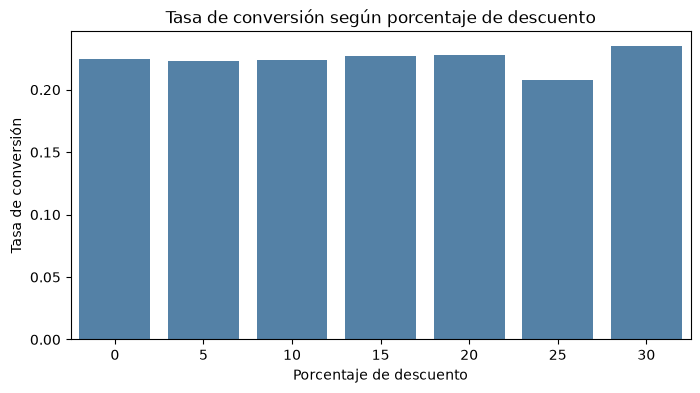

In [95]:
data["purchased_num"] = data[TARGET].astype(int)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=data,
    x="discount_percent",
    y="purchased_num",
    estimator=np.mean,
    errorbar=None,
    color="steelblue"
)

plt.title("Tasa de conversión según porcentaje de descuento")
plt.xlabel("Porcentaje de descuento")
plt.ylabel("Tasa de conversión")
plt.show()

Este análisis permite observar si los descuentos se asocian a una mayor probabilidad de compra. En etapas posteriores, esta información podria ayudar a definir reglas de promociones personalizadas.

## Definición de promociones a aplicar

Dado que el dataset no incluye variables demográficas individuales, se opta por una personalización por **segmento de comportamiento**, enfocada en usuarios nuevos (`user_type = 0`), ya que son el segmento sobre el que tiene sentido aplicar incentivos de primera compra.

### 1. Descuento de recuperación de carrito para usuarios nuevos

Se identifican usuarios nuevos que agregaron algún producto al carrito pero no finalizaron la compra (`user_type = 0`, `added_to_cart = 1`, `purchased = 0`). Este segmento representa 5.173 sesiones, con una mediana de 864 segundos (~14 minutos) de navegación. Se propone ofrecer un descuento de recuperación de carrito a este segmento, apuntando a convertir el interés ya demostrado (agregar al carrito) en una compra concretada.

**Variables relevantes:** `user_type`, `added_to_cart`, `purchased`, `time_on_site_sec`.

### 2. Promoción reforzada por categoría en usuarios móviles nuevos

Entre usuarios nuevos en dispositivo móvil (`user_type = 0`, `device_type = 1`), el tiempo de navegación es similar entre todas las categorías de producto (entre 878 y 932 segundos), sin una categoría que se destaque claramente sobre las demás. Esto indica que el interés de este segmento no está concentrado en una categoría específica, sino distribuido de forma pareja.

**Decisión:** dado que no hay una categoría con ventaja de datos, la elección de qué categoría promocionar queda a criterio del negocio (por ejemplo, por temporada o stock disponible), aplicada sobre el segmento de usuarios nuevos en móvil.

**Variables relevantes:** `user_type`, `device_type`, `product_category`.


## Para Regla 1

In [96]:
segmento_recuperacion_carrito = data[
    (data["user_type"] == 0) &
    (data["added_to_cart"] == 1) &
    (data[TARGET].astype(int) == 0)
]

print(f"Cantidad de sesiones: {len(segmento_recuperacion_carrito)}")
segmento_recuperacion_carrito["time_on_site_sec"].describe()

Cantidad de sesiones: 5173


count    5173.000000
mean      879.090083
std       520.694053
min        10.000000
25%       422.000000
50%       864.000000
75%      1332.000000
max      1799.000000
Name: time_on_site_sec, dtype: float64

## Para la Regla 2

In [97]:
segmento_movil_nuevo = data[
    (data["user_type"] == 0) &
    (data["device_type"] == 1)
]

segmento_movil_nuevo.groupby("product_category", observed=True)["time_on_site_sec"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
product_category,,
3,932.207048,681
2,926.004274,702
1,919.553928,751
0,907.298789,743
6,905.888081,688
4,881.021651,739
5,878.052632,665
7,877.722393,652


In [126]:
mediana_tiempo = data["time_on_site_sec"].median()

data["promocion_1"] = (
    (data["user_type"] == 0) &
    (data["added_to_cart"] == 1) &
    (data[TARGET].astype(int) == 0) &
    (data["time_on_site_sec"] > mediana_tiempo)
)

data["promocion_2"] = (
    (data["user_type"] == 0) &
    (data["device_type"] == 1) &
    (data["time_on_site_sec"] > mediana_tiempo)
)

resumen_promociones = data[["promocion_1", "promocion_2"]].sum().to_frame(name="cantidad_sesiones")
resumen_promociones



,cantidad_sesiones
promocion_1,2472
promocion_2,2830


In [127]:
personas_promocion_1 = data[data["promocion_1"]]["customer_id"].nunique()
personas_promocion_2 = data[data["promocion_2"]]["customer_id"].nunique()

print(f"Personas únicas en promoción 1: {personas_promocion_1}")
print(f"Personas únicas en promoción 2: {personas_promocion_2}")

Personas únicas en promoción 1: 2182
Personas únicas en promoción 2: 2445


## Análisis de navegación

Se evalúa si la intensidad de navegación se relaciona con la conversión.

- Se crea la variable nueva `tiempo_por_pagina`, calculada como `time_on_site_sec / pages_viewed`, para medir la intensidad de navegación (segundos promedio dedicados a cada página vista).

**Nota sobre nomenclatura:** se renombran las columnas de la tabla de resumen para reflejar con precisión lo que representan. Como los valores mostrados son promedios (no datos de una sesión individual), cada columna incluye el prefijo `promedio_`. Además, las columnas que representan tiempo incluyen el sufijo `_seg` (segundos), para no perder de vista la unidad de medida a lo largo del análisis de navegación.

In [99]:
data["tiempo_por_pagina"] = (
    data["time_on_site_sec"] / data["pages_viewed"].replace(0, np.nan)
)

resumen_navegacion = data.groupby(TARGET, observed=True)[[
    "pages_viewed",
    "time_on_site_sec",
    "tiempo_por_pagina"
]].mean().round(2)

resumen_navegacion.columns = [
    "promedio_paginas_vistas",
    "promedio_tiempo_en_sitio_seg",
    "promedio_tiempo_por_pagina_seg"
]

resumen_navegacion

,promedio_paginas_vistas,promedio_tiempo_en_sitio_seg,promedio_tiempo_por_pagina_seg
purchased,,,
0,12.51,895.61,141.23
1,12.62,929.69,142.70


Una mayor navegación puede indicar interés, pero también indecisión. Por eso estas variables deben interpretarse junto con carrito, descuento y resultado de compra.

## Análisis temporal

Se analiza la conversión por mes, día de la semana y temporada para detectar posibles patrones temporales.

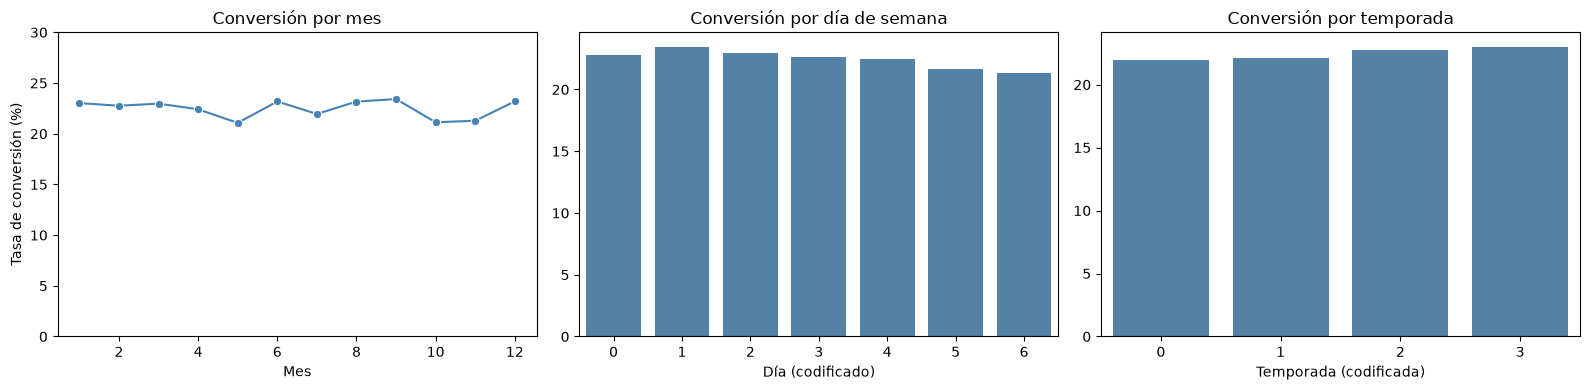

In [103]:
conversion_mes = data.groupby("visit_month", observed=True)[TARGET].apply(lambda x: x.astype(int).mean()).multiply(100).round(2)
conversion_weekday = data.groupby("visit_weekday", observed=True)[TARGET].apply(lambda x: x.astype(int).mean()).multiply(100).round(2)
conversion_season = data.groupby("visit_season", observed=True)[TARGET].apply(lambda x: x.astype(int).mean()).multiply(100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(x=conversion_mes.index, y=conversion_mes.values, marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("Conversión por mes")
axes[0].set_ylim(0, 30)
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Tasa de conversión (%)")

sns.barplot(x=conversion_weekday.index.astype(str), y=conversion_weekday.values, ax=axes[1], color="steelblue")
axes[1].set_title("Conversión por día de semana")
axes[1].set_xlabel("Día (codificado)")
axes[1].set_ylabel("")

sns.barplot(x=conversion_season.index.astype(str), y=conversion_season.values, ax=axes[2], color="steelblue")
axes[2].set_title("Conversión por temporada")
axes[2].set_xlabel("Temporada (codificada)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

**Nota:** el eje Y se fija entre 0% y 30% para evitar que las variaciones menores se vean exageradas visualmente en grafico conversion_mes

**Conclusión:** la tasa de conversión se mantiene prácticamente estable a lo largo del mes, día de la semana y temporada (variaciones menores a 2.5 puntos porcentuales en todos los casos), sin un patrón temporal claro. Esto es consistente con la naturaleza sintética del dataset. Se documenta el hallazgo de forma resumida, sin necesidad de profundizar en gráficos individuales por variable.

## Análisis de productos y categorías

Se revisan categorías y productos desde una perspectiva comercial: conversión, ingresos y abandono.

In [105]:
categoria_resumen = (
    data.groupby("product_category", observed=True)
    .agg(
        sesiones=("session_id", "count"),
        conversion=("purchased", lambda x: x.astype(int).mean()),
        abandono_carrito=("cart_abandoned", lambda x: x.astype(int).mean()),
        ingresos_totales=("revenue", "sum"),
        ingreso_promedio=("revenue", "mean"),
        precio_promedio=("unit_price", "mean")
    )
    .sort_values(by="ingresos_totales", ascending=False)
)

categoria_resumen["conversion"] = categoria_resumen["conversion"] * 100
categoria_resumen["abandono_carrito"] = categoria_resumen["abandono_carrito"] * 100

categoria_resumen.round(2)

,sesiones,conversion,abandono_carrito,ingresos_totales,ingreso_promedio,precio_promedio
product_category,,,,,,
2,3237,22.27,40.93,2037576.79,629.46,1238.58
6,3112,24.68,40.42,1930885.22,620.46,1131.58
5,3149,23.12,43.03,1729167.16,549.12,997.96
3,3040,20.76,41.61,1293649.90,425.54,898.41
7,3073,22.58,42.34,1089617.52,354.58,671.48
0,3142,22.28,42.74,880077.03,280.10,579.68
1,3043,21.26,42.23,702788.87,230.95,455.72
4,3204,22.69,42.73,452406.57,141.20,275.25


**Nota:** en esta sección se utilizan `revenue` y `cart_abandoned`, variables excluidas del modelo predictivo por fuga de información. Su uso aquí es válido, ya que se trata de un análisis descriptivo de negocio (ingresos y abandono por categoría), no de una feature para el modelo de clasificación.

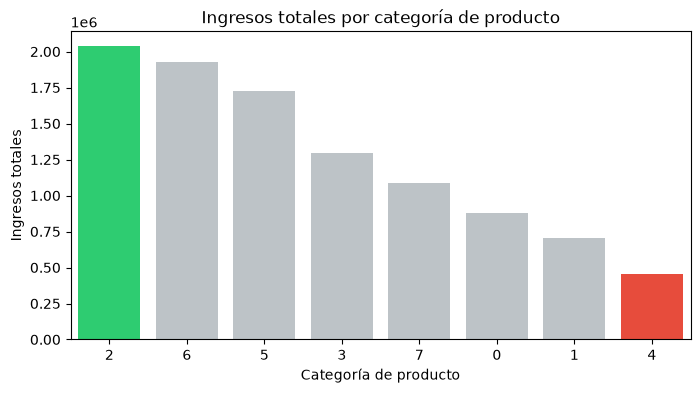

In [112]:
datos_grafico = categoria_resumen.reset_index()
cantidad = len(datos_grafico)

colores = ["#bdc3c7"] * cantidad
colores[0] = "#2ecc71"      # la más alta (primera, ya viene ordenado desc)
colores[-1] = "#e74c3c"     # la más baja (última)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=datos_grafico,
    x="product_category",
    y="ingresos_totales",
    order=datos_grafico["product_category"],
    color="steelblue"
)

for patch, color in zip(ax.patches, colores):
    patch.set_facecolor(color)

plt.title("Ingresos totales por categoría de producto")
plt.xlabel("Categoría de producto")
plt.ylabel("Ingresos totales")
plt.show()

In [113]:
top_productos_ingresos = (
    data.groupby("product_id")
    .agg(
        sesiones=("session_id", "count"),
        compras=("purchased", lambda x: x.astype(int).sum()),
        ingresos_totales=("revenue", "sum"),
        conversion=("purchased", lambda x: x.astype(int).mean())
    )
    .sort_values(by="ingresos_totales", ascending=False)
    .head(10)
)

top_productos_ingresos["conversion"] = top_productos_ingresos["conversion"] * 100

top_productos_ingresos.round(2)

,sesiones,compras,ingresos_totales,conversion
product_id,,,,
130,29,12,35975.88,41.38
292,41,13,33794.75,31.71
806,32,13,32446.56,40.62
49,31,9,32122.48,29.03
453,27,13,31456.73,48.15
696,41,11,30775.59,26.83
175,34,10,30099.90,29.41
686,43,13,30001.75,30.23
634,29,9,29627.73,31.03


Este análisis servirá para asociar promociones o recomendaciones comerciales a categorías y productos con mayor potencial de conversión o mayor abandono.

## Matriz de correlación

Se calcula la correlación entre variables numéricas. El Target si bien no es numerico, se hara la conversion para este analisis puntual.
Para interpretar el modelo de compra hay que tener cuidado con variables posteriores a la compra, como `revenue` y `revenue_normalized`, porque pueden generar fuga de información si se usan como predictoras.

In [115]:
print("Correlación con variable objetivo:\n")

columnas_para_correlacion = [
    "unit_price", "quantity", "discount_percent", "discount_amount",
    "discount_amount_log", "pages_viewed", "time_on_site_sec", "tiempo_por_pagina"
]

data_corr = data[columnas_para_correlacion].copy()
data_corr["purchased_num"] = data[TARGET].astype(int)

correlations = (
    data_corr.corr()["purchased_num"]
    .drop("purchased_num")
    .sort_values(ascending=False)
    .round(2)
)

print(correlations)

Correlación con variable objetivo:

time_on_site_sec       0.03
unit_price             0.01
pages_viewed           0.01
quantity               0.00
discount_amount        0.00
tiempo_por_pagina      0.00
discount_amount_log    0.00
discount_percent       0.00
Name: purchased_num, dtype: float64


## Asociación entre variables categóricas y la variable objetivo (V de Cramér)

Para variables categóricas (donde los números son etiquetas, no cantidades), no se puede calcular una correlación de Pearson tradicional. En su lugar, se usa la **V de Cramér**, una medida que indica qué tan asociada está cada categoría con el resultado de compra.

In [116]:
from scipy.stats import chi2_contingency

def cramers_v(columna, target=TARGET, df=data):
    tabla = pd.crosstab(df[columna], df[target])
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return round((chi2 / (n * (min(tabla.shape) - 1))) ** 0.5, 3)

columnas_categoricas_finales = [
    "device_type", "user_type", "marketing_channel",
    "product_category", "payment_method", "location", "visit_season"
]

resultados = pd.DataFrame({
    "variable": columnas_categoricas_finales,
    "cramers_v": [cramers_v(col) for col in columnas_categoricas_finales]
}).sort_values("cramers_v", ascending=False)

resultados

,variable,cramers_v
5,location,0.090
1,user_type,0.085
3,product_category,0.026
4,payment_method,0.016
2,marketing_channel,0.015
6,visit_season,0.010
0,device_type,0.006


**¿Cómo se interpreta el resultado?** La V de Cramér da un número entre 0 y 1:
- Cercano a **0**: no hay relación aparente entre esa variable y la compra.
- Cercano a **1**: la variable está fuertemente asociada a si la sesión termina en compra o no.
- Como referencia general: valores por debajo de 0.1 se consideran una asociación débil o despreciable; entre 0.1 y 0.3, moderada; por encima de 0.3, fuerte.

El cálculo se basa en el test de Chi-cuadrado, que compara la distribución real de los datos contra la que se esperaría si no hubiera ninguna relación entre las dos variables — cuanto mayor la diferencia, mayor la asociación.

**Interpretación:** ninguna variable categórica individual supera el umbral de asociación "débil" (0.1) con la variable objetivo. `location` (0.09) y `user_type` (0.085) son las que más se acercan, consistente con la diferencia de conversión observada previamente entre usuarios nuevos y recurrentes. El resto de las variables (`product_category`, `payment_method`, `marketing_channel`, `visit_season`, `device_type`) muestran una asociación despreciable de forma individual.

Esto no implica que estas variables sean inútiles para el modelo: un algoritmo basado en árboles puede capturar interacciones entre variables (por ejemplo, la combinación de dispositivo + categoría + descuento) que no se detectan al analizar cada variable por separado. La ausencia de señal individual fuerte es información relevante para elegir el tipo de modelo a utilizar en la etapa siguiente.

Matriz de Correlación:
 


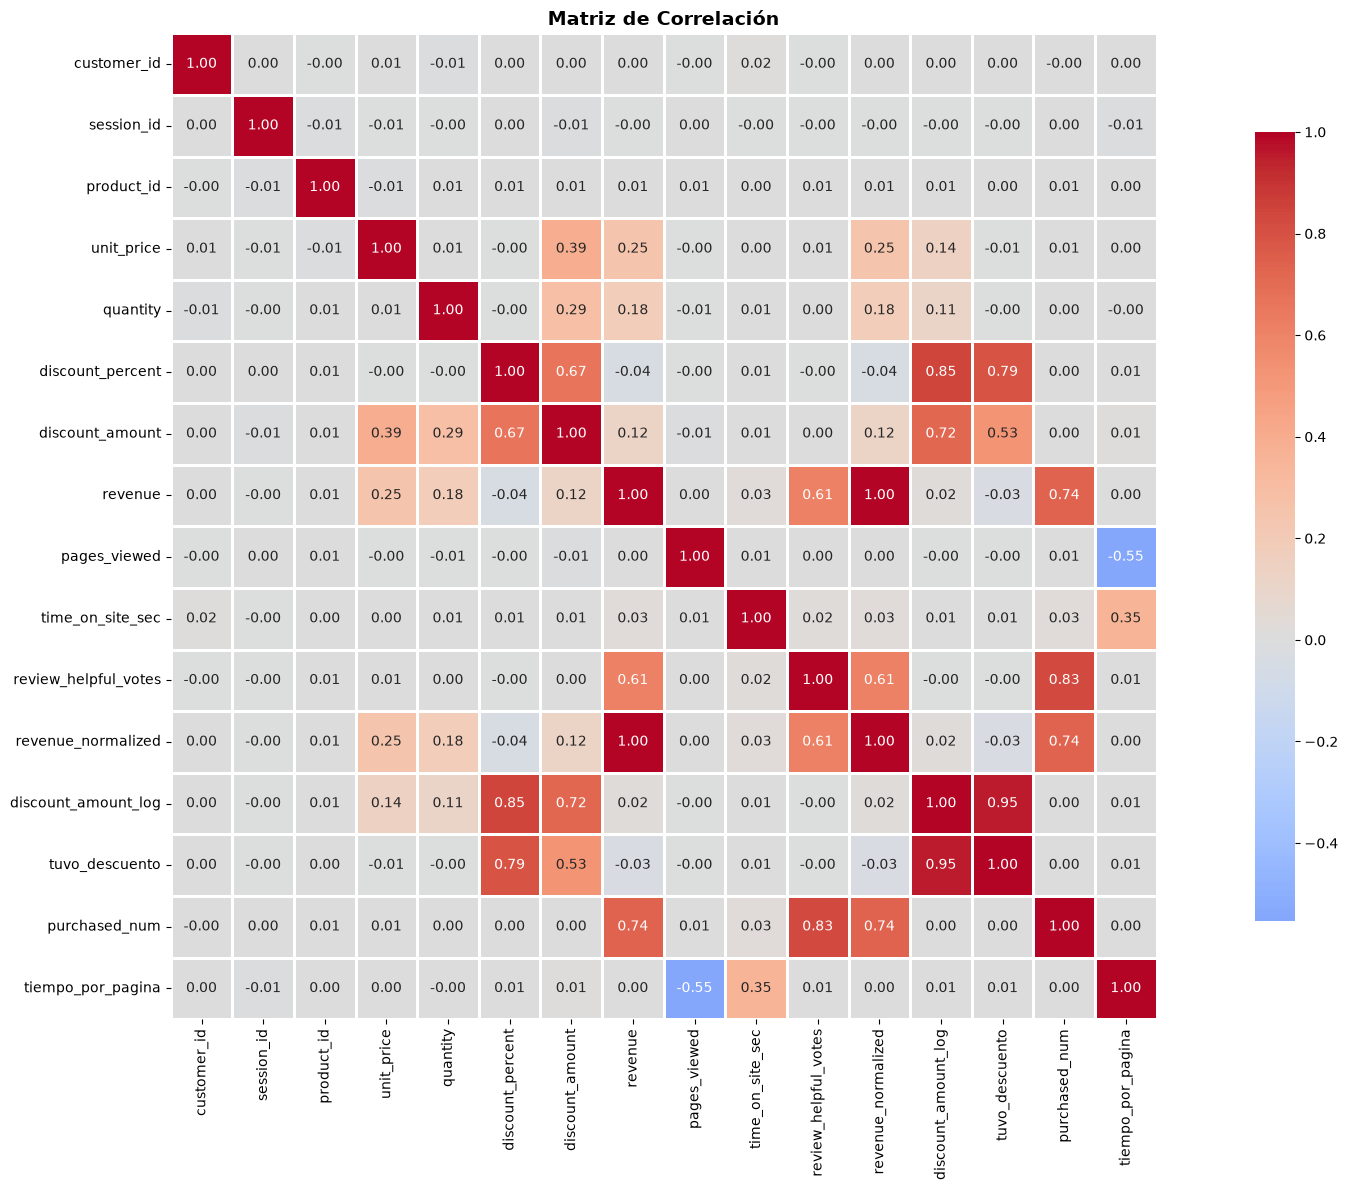

In [117]:
# Evaluación de Multicolinealidad
print("Matriz de Correlación:\n ")

correlation = data.drop(TARGET, axis = 1).corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Mejora de analisis de multicolinealidad:

se restringe el análisis de multicolinealidad a las variables numéricas seleccionadas para el modelo, excluyendo las variables con fuga de información. Esto permite detectar si alguna pareja de features está muy correlacionada entre sí (lo cual podría ser redundante para el modelo), sin la distracción de columnas que de todas formas no se van a usar.

Matriz de Correlación (variables numéricas finales):



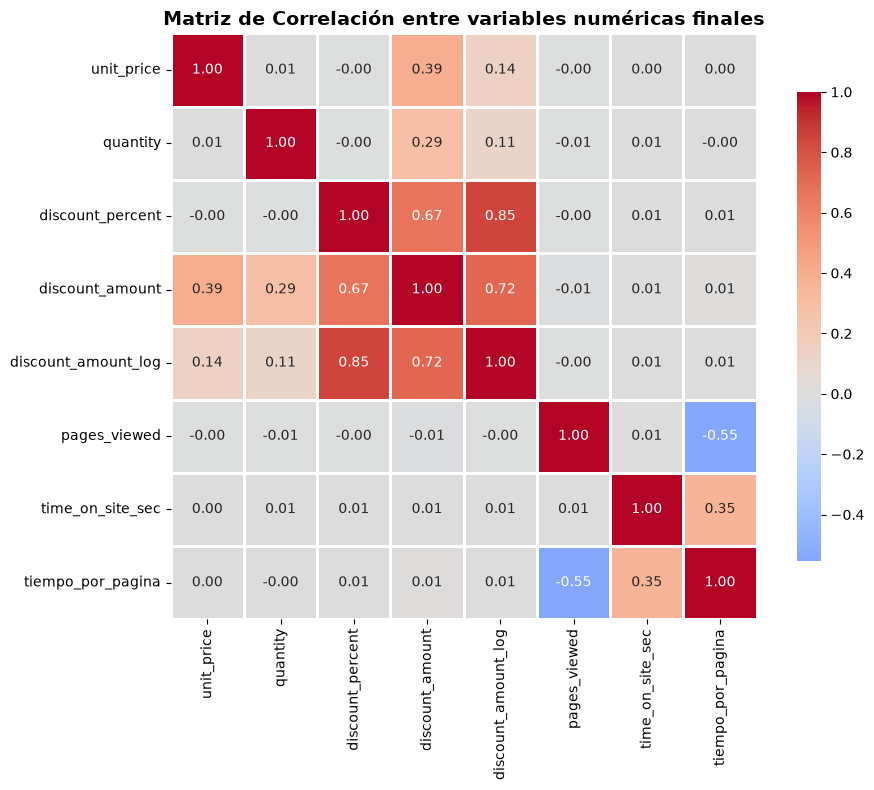

In [119]:
print("Matriz de Correlación (variables numéricas finales):\n")

columnas_numericas_finales = [
    "unit_price", "quantity", "discount_percent", "discount_amount",
    "discount_amount_log", "pages_viewed", "time_on_site_sec", "tiempo_por_pagina"
]

correlation = data[columnas_numericas_finales].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre variables numéricas finales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

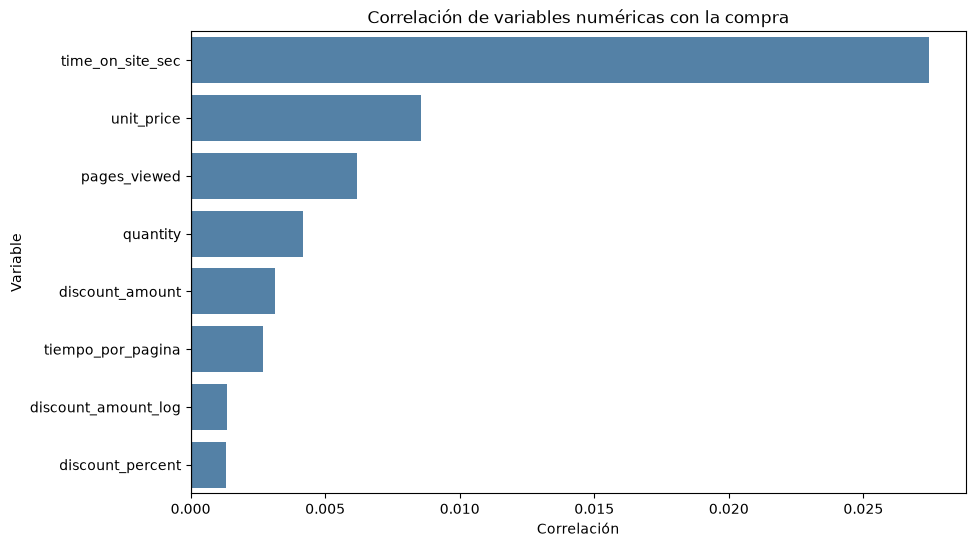

In [120]:
correlacion_target = data_corr.corr()["purchased_num"].drop("purchased_num").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=correlacion_target.values,
    y=correlacion_target.index,
    color="steelblue"
)
plt.title("Correlación de variables numéricas con la compra")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

## Variables con posible fuga de información

Para el modelado posterior se deben revisar variables que podrían no estar disponibles antes de conocer el resultado de la compra.

Variables a tratar con cuidado:

- `revenue`: solo existe si hubo compra.
- `revenue_normalized`: deriva de revenue.
- `cart_abandoned`: describe si una sesión terminó con carrito abandonado.
- `visit_day`, `visit_month`, `visit_weekday`: no son leakage, son solo redundantes con visit_date.
- `rating`, `review_text` y `review_helpful_votes`: representan información posterior a la compra

Esta revisión es importante para evitar entrenar un modelo con información que en un escenario real no estaría disponible al momento de predecir.

## Dataset preliminar para modelado

A partir del EDA, se puede dejar una primera propuesta de variables candidatas para modelar intención de compra.  
Esta selección puede ajustarse en la etapa de ingeniería de características.

In [130]:
variables_candidatas_modelo = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount_log",
    "pages_viewed",
    "time_on_site_sec",
    "tiempo_por_pagina",
    "tuvo_descuento",
    "added_to_cart",
    "payment_method",
    "visit_date",
    "visit_season",
    "location",
    "promocion_1",
    "promocion_2"
]

variables_a_excluir_por_leakage = [
    "revenue",
    "revenue_normalized",
    "cart_abandoned",
    "rating",
    "review_text",
    "review_helpful_votes"
]

variables_excluidas_por_redundancia = [
    "visit_day",
    "visit_month",
    "visit_weekday",
    "session_duration_bucket"
]

print("Variables candidatas para modelado:")
print(variables_candidatas_modelo)

print("\nVariables excluidas por fuga de información (leakage):")
print(variables_a_excluir_por_leakage)

print("\nVariables excluidas por redundancia:")
print(variables_excluidas_por_redundancia)

Variables candidatas para modelado:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount_log', 'pages_viewed', 'time_on_site_sec', 'tiempo_por_pagina', 'tuvo_descuento', 'added_to_cart', 'payment_method', 'visit_date', 'visit_season', 'location', 'promocion_1', 'promocion_2']

Variables excluidas por fuga de información (leakage):
['revenue', 'revenue_normalized', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes']

Variables excluidas por redundancia:
['visit_day', 'visit_month', 'visit_weekday', 'session_duration_bucket']


### Actualización: variables temporales (día, mes, semana, fecha)

 `visit_day`, `visit_month`, `visit_weekday` y `visit_season` **mantener todas disponibles** en el dataset de variables candidatas, por dos motivos:

1. Pueden resultar útiles para la definición de promociones o reportes de negocio (por ejemplo, promociones atadas a un día, mes o temporada específica), aunque no aporten señal fuerte al modelo de clasificación.
2. Permiten comparar el desempeño de distintos modelos incluyendo o excluyendo variables temporales, una vez que se defina el modelo final a entrenar.


In [ ]:
variables_candidatas_modelo = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "pages_viewed",
    "time_on_site_sec",
    "tiempo_por_pagina",
    "added_to_cart",
    "payment_method",
    "visit_date",
    "visit_day",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "location",
    "promocion_1",
    "promocion_2"
]

variables_a_excluir_por_leakage = [
    "revenue",
    "revenue_normalized",
    "cart_abandoned",
    "rating",
    "review_text",
    "review_helpful_votes"
]

variables_excluidas_por_redundancia = [
    "session_duration_bucket"
]

print("Variables candidatas para modelado:")
print(variables_candidatas_modelo)

print("\nVariables excluidas por fuga de información (leakage):")
print(variables_a_excluir_por_leakage)

print("\nVariables excluidas por redundancia:")
print(variables_excluidas_por_redundancia)

Variables candidatas para modelado:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'discount_amount_log', 'pages_viewed', 'time_on_site_sec', 'tiempo_por_pagina', 'tuvo_descuento', 'added_to_cart', 'payment_method', 'visit_date', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'location', 'promocion_1', 'promocion_2']

Variables excluidas por fuga de información (leakage):
['revenue', 'revenue_normalized', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes']

Variables excluidas por redundancia:
['session_duration_bucket']


## Variables Nuevas Creadas.

| Variable | Cálculo |
|---|---|
| `tuvo_descuento` | `discount_percent > 0` |
| `tiempo_por_pagina` | `time_on_site_sec / pages_viewed` |
| `promocion_1` | `user_type=0 & added_to_cart=1 & purchased=0 & time_on_site_sec > mediana` |
| `promocion_2` | `user_type=0 & device_type=1 & time_on_site_sec > mediana` |

## Conclusiones preliminares

- El dataset contiene 25.000 sesiones de e-commerce con información útil sobre navegación, carrito, descuentos, producto, pago y compra.
- La variable `purchased` permite plantear un problema de clasificación para predecir intención de compra.
- Los KPIs principales del proyecto son la tasa de conversión y la tasa de abandono de carrito.
- Las variables relacionadas con carrito, descuento, navegación y categoría de producto pueden ser especialmente relevantes para diseñar promociones personalizadas.
- Algunas variables deben revisarse antes del modelado para evitar fuga de información, especialmente `revenue`, `revenue_normalized` y `cart_abandoned`.
- El análisis permite avanzar hacia un modelo predictivo que estime la probabilidad de compra y luego traduzca esa probabilidad en acciones comerciales personalizadas.

## Próximos pasos

1. Definir con precisión las variables que estarán disponibles antes de la compra.
2. Preparar el dataset para modelado.
3. Codificar variables categóricas.
4. Entrenar modelos de clasificación para predecir `purchased`.
5. Evaluar el modelo con métricas adecuadas para negocio.
6. Definir reglas de promociones personalizadas según probabilidad de compra, carrito y segmento de usuario.